In [1]:
import nltk

In [2]:
papers = {
    'Madison':[10,14,37,38,39,40,41,42,43,44,45,46,47,48],
    'Hamilton':[1,6,7,8,9,11,12,13,15,16,17,21,22,23,
                24,25,26,27,28,29,30,31,32,33,34,35,36,59,
                60,61,65,66,67,68,69,70,71,72,73,74,75,76,77,
                78,79,80,81,82,83,84,85],
    'Jay':[2,3,4,5],
    'Shared' : [18,19,20],
    'Disputed' : [49,50,51,52,53,54,55,56,57,58,62,63]
}

In [3]:
def read_files(filename):
        strings = []
        for file in filename:
            try:
                with open(f'federalist_{file}.txt') as f:
                    strings.append(f.read())
            except FileNotFoundError:
                print(f"File federalist_{file}.txt not found")
        return ('\n'.join(strings))

In [4]:
federalist_author = {}
for author , files in papers.items():
    federalist_author[author] = read_files(files)

In [5]:
authors = ('Hamilton','Madison','Disputed','Jay','Shared')
author_tokens = {}
length_distribution = {}

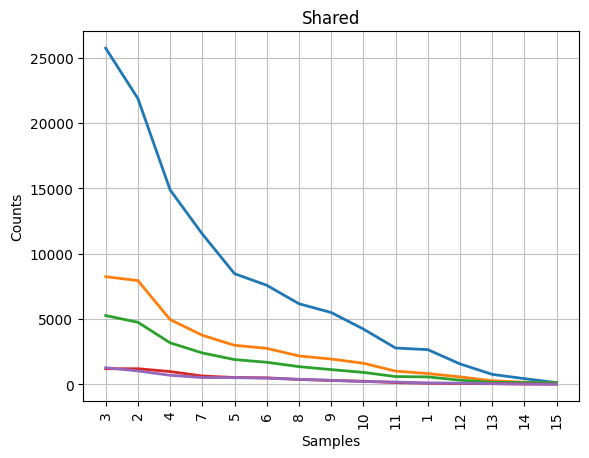

In [6]:
for author in authors:
    text = federalist_author.get(author)

    if not text:
        print(f"No data for {author}")
        continue

    tokens = nltk.word_tokenize(text)

    author_tokens[author] = [
        token for token in tokens if any(c.isalpha() for c in token)
    ]

    token_lengths = [len(token) for token in author_tokens[author]]

    length_distribution[author] = nltk.FreqDist(token_lengths)
    length_distribution[author].plot(15, title=author)